In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    cohen_kappa_score, matthews_corrcoef, roc_auc_score
)
import pandas as pd

# =========================
# 1. Preparar datos
# =========================
result_folder = "../data/result"
path = final_csv = f"{result_folder}/df_final.csv"
df = pd.read_csv(path, delimiter=',')

X = df.drop(columns=["label", "HC50"])
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =========================
# 2. Pipeline con imputación, escalado y SVM
# =========================
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
    ("svm", SVC(probability=True, class_weight="balanced", random_state=42))
])

# =========================
# 3. GridSearch para hiperparámetros
# =========================
param_grid = {
    "svm__C": [0.1, 1, 10],
    "svm__gamma": ["scale", "auto"],
    "svm__kernel": ["linear", "rbf"]
}

grid = GridSearchCV(
    pipeline, param_grid, cv=5, scoring="f1", n_jobs=-1
)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_

# =========================
# 4. Evaluación en test
# =========================
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1-score": f1_score(y_test, y_pred),
    "Cohen's Kappa": cohen_kappa_score(y_test, y_pred),
    "MCC": matthews_corrcoef(y_test, y_pred),
    "AUC-ROC": roc_auc_score(y_test, y_proba),
}

print("Best Params:", grid.best_params_)
print(pd.DataFrame(metrics, index=["SVM"]))


Best Params: {'svm__C': 10, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
     Accuracy  Precision    Recall  F1-score  Cohen's Kappa       MCC  \
SVM     0.775   0.759036  0.797468  0.777778       0.550211  0.550899   

      AUC-ROC  
SVM  0.846031  


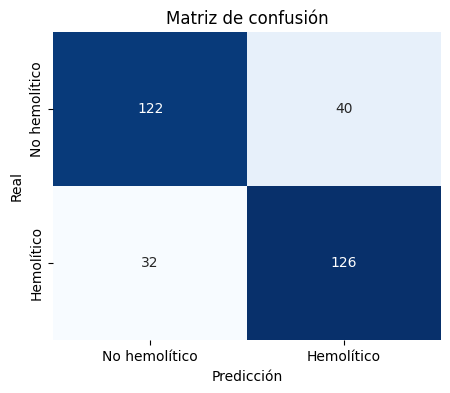

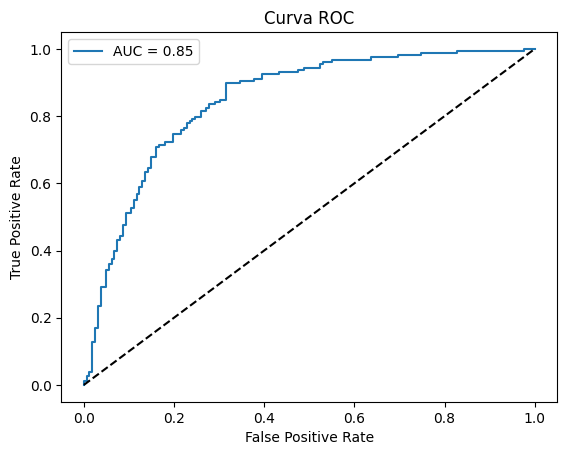

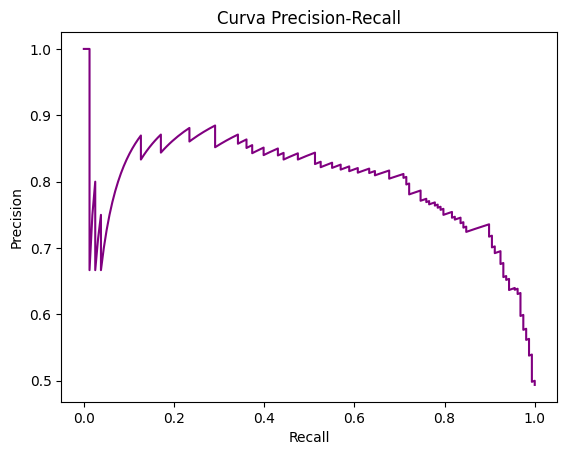

In [9]:
from sklearn.metrics import confusion_matrix, roc_curve, precision_recall_curve
import seaborn as sns
import matplotlib.pyplot as plt

# ======================
# Matriz de confusión
# ======================
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["No hemolítico", "Hemolítico"],
            yticklabels=["No hemolítico", "Hemolítico"])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión")
plt.show()

# ======================
# Curva ROC
# ======================
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {metrics['AUC-ROC']:.2f}")
plt.plot([0,1], [0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.legend()
plt.show()

# ======================
# Curva Precision-Recall
# ======================
prec, rec, _ = precision_recall_curve(y_test, y_proba)
plt.figure()
plt.plot(rec, prec, color="purple")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall")
plt.show()
